```
Copyright 2026 Google LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    https://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
```

In [ ]:
from IPython.display import display
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

rng = np.random.default_rng()

In [ ]:
# Use styling that is consistent with empirical analysis
entropy_colors = {
    'Shannon': 'black',
    'Norm Shannon': 'black',
    'Tsallis': 'black',
}
entropy_lines = {
    'Shannon': '-',
    'Norm Shannon': ':',
    'Tsallis': '-.',
}
entropy_labels = {
    'Shannon': 'Shannon',
    'Norm Shannon': 'Normalized',
    'Tsallis': 'Tsallis',
}
# Use consistent domain size/range with plots
DOMAIN_MAX = 10000 # 10k
N = DOMAIN_MAX
domain_sizes = list(range(1, DOMAIN_MAX + 1))


In [ ]:
from scipy.stats import entropy
# shannon entropy (standard measurement)

def get_shannon_entropy(pk):
  assert(pk.sum().round(10) == 1)
  return entropy(pk, base=2) # unit is bits

def get_normalized_shannon_entropy(pk, N):
  assert(pk.sum().round(10) == 1)
  return get_shannon_entropy(pk)/math.log(N, 2)

def get_tsallis_entropy(pk):
  assert(pk.sum().round(10) == 1)
  return 1 - pk.pow(2).sum()

## Example 1

|X|=10, H(X)=3.32


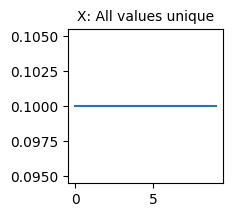

In [ ]:
def get_pX_all_unique(D):
  return pd.Series([1/D]*D)

D = 10
pX = get_pX_all_unique(D)
print('|X|=%s, H(X)=%0.2f' % (D, get_shannon_entropy(pX)))
fig, ax = plt.subplots(1,1, figsize=(2,2))
ax.set_title('X: All values unique', fontdict={'fontsize':10})
_ = ax.plot(pX)

X follows power law distribution
sum(X)=1.000
|X|=10000, H(X)=9.53


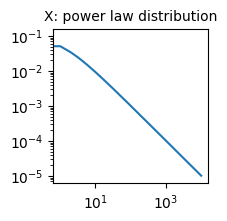

In [ ]:
def get_pX_power_law_dist(domain_size):
  """f(x)=x^(-1)"""
  X = np.array([1 / (d + 1) for d in range(domain_size)])
  X = X / sum(X)
  return pd.Series(X)

# D = 100
# D = 1000
D = DOMAIN_MAX
pX = get_pX_power_law_dist(D)
print('X follows power law distribution')
print('sum(X)=%0.3f' % sum(pX))
print('|X|=%s, H(X)=%0.2f' % (D, get_shannon_entropy(pX)))
fig, ax = plt.subplots(1,1, figsize=(2,2))
ax.set_title('X: power law distribution', fontdict={'fontsize':10})
_ = ax.plot(pX)
_ = ax.set_xscale('log')
_ = ax.set_yscale('log')

In [ ]:
""""
1.A
Samples of increasing size, ranging from n=1 to 10,000, are drawn from a population
distributed by the power law, f(x)=x-1, where the true domain size is 10,000.
For each sample, we take the observed domain size and entropy estimated for the sample, averaged over 100 trials

"""
ns = [int(n) for n in np.logspace(1, 4, 100)]
D = DOMAIN_MAX #= 10000 # 10k
trials = 100
print('domain size %s; T=%s trials' % (D, trials))

pX = get_pX_power_law_dist(D)
avg_observed_domains = []
avg_shannon_entropy_values = []
avg_norm_shannon_entropy_values = []
avg_tsallis_entropy_values = []
for n in ns:
  if n%1000 == 0:
    print(n)
  observed_domain = 0
  H_hat = 0
  NormH_hat = 0
  T_hat = 0
  for t in range(trials):
    # Draw samples from distribution
    samples = rng.choice(D, size=n, p=pX)
    observed_domain += len(set(samples))
    # Estimate entropies from samples
    _, counts = np.unique(samples, return_counts=True)
    p_hat = pd.Series(counts / sum(counts))
    H_hat += get_shannon_entropy(p_hat)
    NormH_hat += get_normalized_shannon_entropy(p_hat, N=n)
    T_hat += get_tsallis_entropy(p_hat)
  # Take the average
  avg_observed_domains += [observed_domain/trials]
  avg_shannon_entropy_values += [H_hat/trials]
  avg_norm_shannon_entropy_values += [NormH_hat/trials]
  avg_tsallis_entropy_values += [T_hat/trials]

data_1A_v1 = pd.DataFrame({
    'n': ns,
    'domain': avg_observed_domains,
    'Shannon': avg_shannon_entropy_values,
    'Norm Shannon': avg_norm_shannon_entropy_values,
    'Tsallis': avg_tsallis_entropy_values,
}).set_index('n')
data_1A_v1.head()

domain size 10000; T=100 trials
1000
10000


,domain,Shannon,Norm Shannon,Tsallis
n,,,,
10,9.43,3.199889,0.963263,0.886400
10,9.39,3.189889,0.960252,0.885000
11,10.30,3.320437,0.959822,0.894380
12,11.13,3.427193,0.955991,0.901667
13,11.79,3.494226,0.944273,0.904379


The cell below generates **Figure 1 (bottom)** of the paper: *Shannon entropy increases with $n$ (example 1). Top shows the extreme case where all values are unique. Bottom shows the case where values are distributed by the power law.*

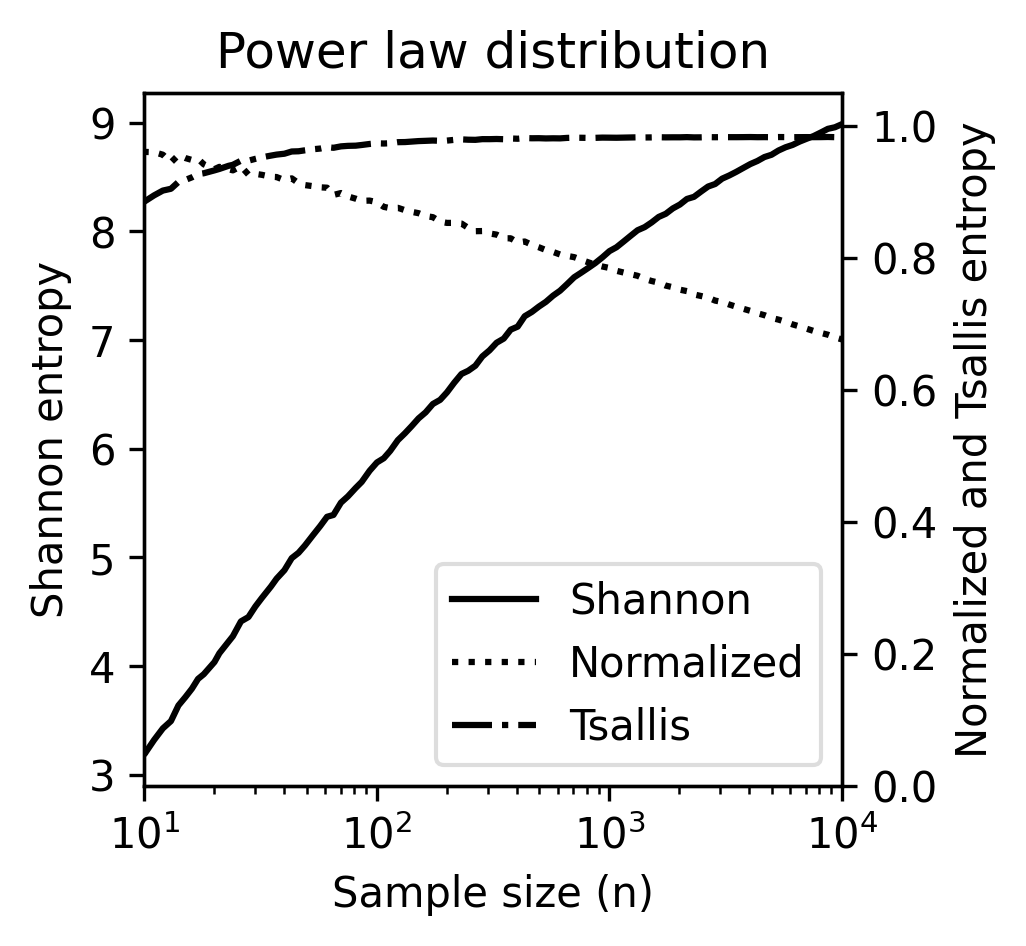

In [ ]:
data = data_1A_v1
fig, ax = plt.subplots(1,1, figsize=(3,3), dpi=300)
ax.set_title('Power law distribution')
lns = ax.plot(data.index, data['Shannon'], entropy_lines['Shannon'], label=entropy_labels['Shannon'], color=entropy_colors['Shannon'])
ax.set_ylabel('Shannon entropy')
#ax.set_yticks([3,5,7,9])
ax2 = ax.twinx()
ax2.set_ylim(0, 1.05)
ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
lns += ax2.plot(data.index, data['Norm Shannon'], entropy_lines['Norm Shannon'], label=entropy_labels['Norm Shannon'], color=entropy_colors['Norm Shannon'])
ax2.set_ylabel('Normalized and Tsallis entropy')
lns += ax2.plot(data.index, data['Tsallis'], entropy_lines['Tsallis'], label=entropy_labels['Tsallis'], color=entropy_colors['Tsallis'])
ax.set_xscale('log')
ax.set_xticks([10,100,1000,10000])
ax.set_xlim(10, 10000)
ax.set_xlabel('Sample size (n)')

labs = [l.get_label() for l in lns]
_ = plt.legend(lns, labs, loc='lower right', facecolor='white', framealpha=0.65)

The cell below generates **Figure 8** (Appendix A.1) of the paper: *Figure 1 (bottom plot) replicated with observed domain size on the x-axis.*

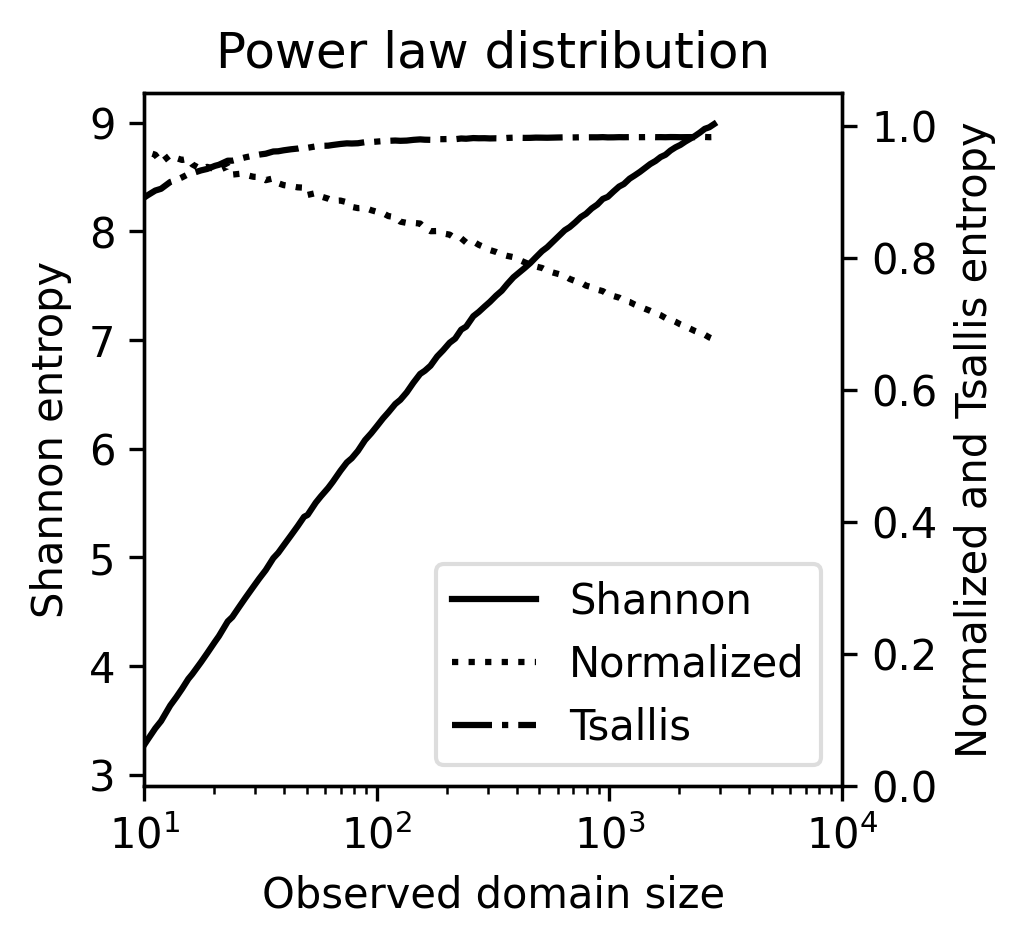

In [ ]:
data = data_1A_v1
fig, ax = plt.subplots(1,1, figsize=(3,3), dpi=300)
ax.set_title('Power law distribution')
lns = ax.plot(data['domain'], data['Shannon'], entropy_lines['Shannon'], label=entropy_labels['Shannon'], color=entropy_colors['Shannon'])
ax.set_ylabel('Shannon entropy')
#ax.set_yticks([3,5,7,9])
ax2 = ax.twinx()
ax2.set_ylim(0, 1.05)
ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
lns += ax2.plot(data['domain'], data['Norm Shannon'], entropy_lines['Norm Shannon'], label=entropy_labels['Norm Shannon'], color=entropy_colors['Norm Shannon'])
ax2.set_ylabel('Normalized and Tsallis entropy')
lns += ax2.plot(data['domain'], data['Tsallis'], entropy_lines['Tsallis'], label=entropy_labels['Tsallis'], color=entropy_colors['Tsallis'])
ax.set_xscale('log')
ax.set_xticks([10,100,1000,10000])
ax.set_xlim(10, 10000)
ax.set_xlabel('Observed domain size')

labs = [l.get_label() for l in lns]
_ = plt.legend(lns, labs, loc='lower right', facecolor='white', framealpha=0.65)

In [ ]:
"""
1.B.v1
Samples of increasing size, ranging from n=1 to 10,000, are drawn from a population
where all values are unique and the true domain size is 10,000.
For each sample, we plot the observed domain size and entropy estimated for the sample.
"""
N_MAX = 10000
ns = [int(n) for n in np.logspace(1, 4, 100)]
D = DOMAIN_MAX #= 10000 # 10k
print('N max=%s; domain size %s' % (N_MAX, D))

pX = get_pX_all_unique(D)
observed_domains = []
shannon_entropy_values = []
norm_shannon_entropy_values = []
tsallis_entropy_values = []
for n in ns:
  if n%1000 == 0: print(n)
  # Draw samples from distribution
  samples = rng.choice(D, size=n, p=pX, replace=False)
  observed_domains += [len(set(samples))]
  # Estimate entropies from samples
  _, counts = np.unique(samples, return_counts=True)
  p_hat = pd.Series(counts / sum(counts))
  H_hat = get_shannon_entropy(p_hat)
  NormH_hat = get_normalized_shannon_entropy(p_hat, N=n)
  T_hat = get_tsallis_entropy(p_hat)
  shannon_entropy_values += [H_hat]
  norm_shannon_entropy_values += [NormH_hat]
  tsallis_entropy_values += [T_hat]

data_1B_v1 = pd.DataFrame({
    'n': ns,
    'domain': observed_domains,
    'Shannon': shannon_entropy_values,
    'Norm Shannon': norm_shannon_entropy_values,
    'Tsallis': tsallis_entropy_values,
}).set_index('n')
data_1B_v1.head()

N max=10000; domain size 10000
1000
10000


,domain,Shannon,Norm Shannon,Tsallis
n,,,,
10,10,3.321928,1.0,0.900000
10,10,3.321928,1.0,0.900000
11,11,3.459432,1.0,0.909091
12,12,3.584963,1.0,0.916667
13,13,3.700440,1.0,0.923077


The cell below generates **Figure 1 (top)** of the paper: *Shannon entropy increases with $n$ (example 1). Top shows the extreme case where all values are unique. Bottom shows the case where values are distributed by the power law.*

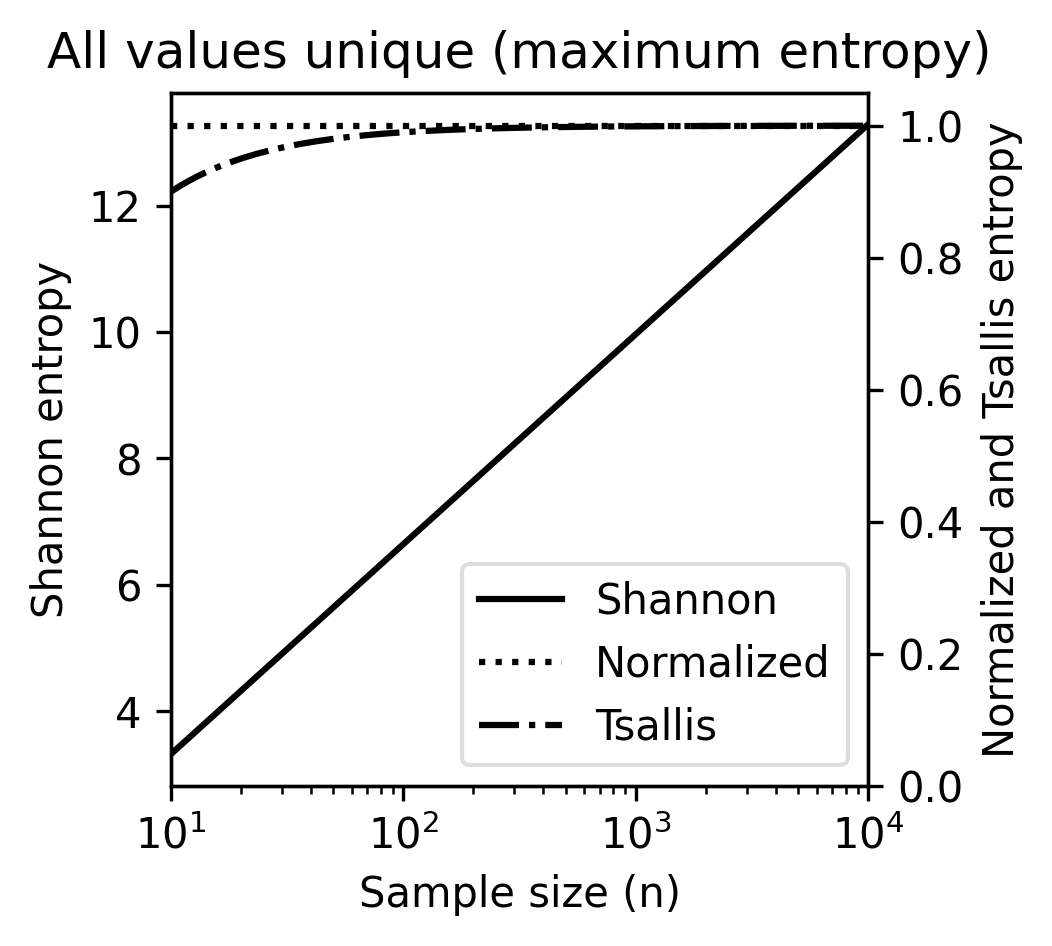

In [ ]:
data = data_1B_v1
fig, ax = plt.subplots(1,1, figsize=(3,3), dpi=300)
ax.set_title('All values unique (maximum entropy)')
lns = ax.plot(data.index, data['Shannon'], entropy_lines['Shannon'], label=entropy_labels['Shannon'], color=entropy_colors['Shannon'])
ax.set_ylabel('Shannon entropy')
ax2 = ax.twinx()
ax2.set_ylim(0, 1.05)
ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
lns += ax2.plot(data.index, data['Norm Shannon'], entropy_lines['Norm Shannon'], label=entropy_labels['Norm Shannon'], color=entropy_colors['Norm Shannon'])
ax2.set_ylabel('Normalized and Tsallis entropy')
lns += ax2.plot(data.index, data['Tsallis'], entropy_lines['Tsallis'], label=entropy_labels['Tsallis'], color=entropy_colors['Tsallis'])
ax.set_xscale('log')
ax.set_xticks([10,100,1000,10000])
ax.set_xlim(10, 10000)
ax.set_xlabel('Sample size (n)')

labs = [l.get_label() for l in lns]
_ = plt.legend(lns, labs, loc='lower right', facecolor='white', framealpha=0.65)

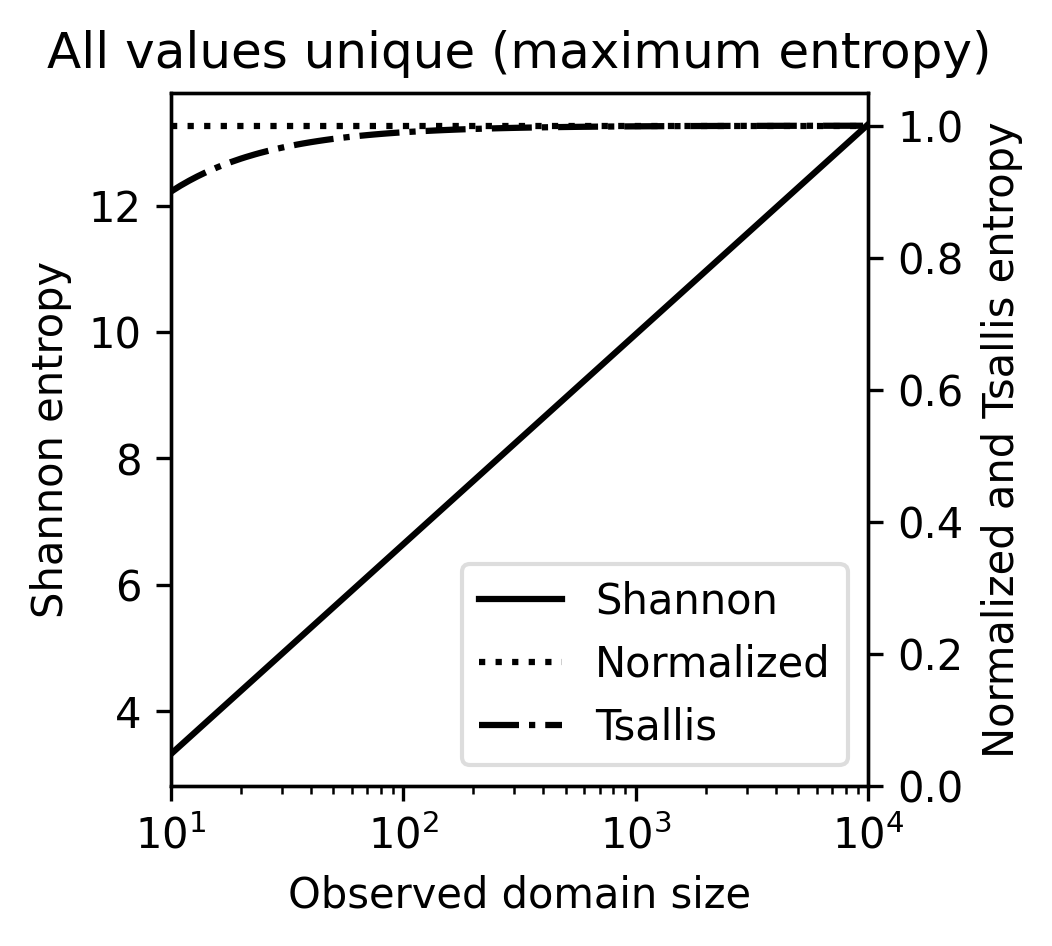

In [ ]:
data = data_1B_v1
fig, ax = plt.subplots(1,1, figsize=(3,3), dpi=300)
ax.set_title('All values unique (maximum entropy)')
lns = ax.plot(data['domain'], data['Shannon'], entropy_lines['Shannon'], label=entropy_labels['Shannon'], color=entropy_colors['Shannon'])
ax.set_ylabel('Shannon entropy')
ax2 = ax.twinx()
ax2.set_ylim(0, 1.05)
ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
lns += ax2.plot(data['domain'], data['Norm Shannon'], entropy_lines['Norm Shannon'], label=entropy_labels['Norm Shannon'], color=entropy_colors['Norm Shannon'])
ax2.set_ylabel('Normalized and Tsallis entropy')
lns += ax2.plot(data['domain'], data['Tsallis'], entropy_lines['Tsallis'], label=entropy_labels['Tsallis'], color=entropy_colors['Tsallis'])

ax.set_xscale('log')
ax.set_xticks([10,100,1000,10000])
ax.set_xlim(10, 10000)
ax.set_xlabel('Observed domain size')

labs = [l.get_label() for l in lns]
_ = plt.legend(lns, labs, loc='lower right', facecolor='white', framealpha=0.65)

## Example 2

Normalized entropy is dependent on sample size.

Show: Uniform distribution with domain of size 2

Sample size ranges from 1 to N=10k


p(X)=
0    0.5
1    0.5
dtype: float64
X follows uniform distribution
sum(X)=1.000
|X|=10000, H(X)=1.00


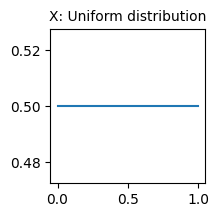

In [ ]:
pX = pd.Series([1/2, 1/2])
print('p(X)=')
print(pX)
print('X follows uniform distribution')
print('sum(X)=%0.3f' % sum(pX))
print('|X|=%s, H(X)=%0.2f' % (D, get_shannon_entropy(pX)))
fig, ax = plt.subplots(1,1, figsize=(2,2))
ax.set_title('X: Uniform distribution', fontdict={'fontsize':10})
_ = ax.plot(pX)

In [ ]:
print('max N=%s'%N)
sample_sizes = list(range(10, N+1))

shannon_entropy_values = []
norm_shannon_entropy_values = []
tsallis_entropy_values = []
for n in sample_sizes:
  #if n > 10: break
  shannon_entropy_values += [get_shannon_entropy(pX)]
  norm_shannon_entropy_values += [get_normalized_shannon_entropy(pX, N=n)]
  tsallis_entropy_values += [get_tsallis_entropy(pX)]

data_2 = pd.DataFrame({
    'n': sample_sizes,
    'Shannon': shannon_entropy_values,
    'Norm Shannon': norm_shannon_entropy_values,
    'Tsallis': tsallis_entropy_values,
}).set_index('n')
data_2.head()

max N=10000


,Shannon,Norm Shannon,Tsallis
n,,,
10,1.0,0.301030,0.5
11,1.0,0.289065,0.5
12,1.0,0.278943,0.5
13,1.0,0.270238,0.5
14,1.0,0.262650,0.5


The cell below generates **Figure 2** of the paper: *Normalized entropy decreases with $n$ (example 2).*

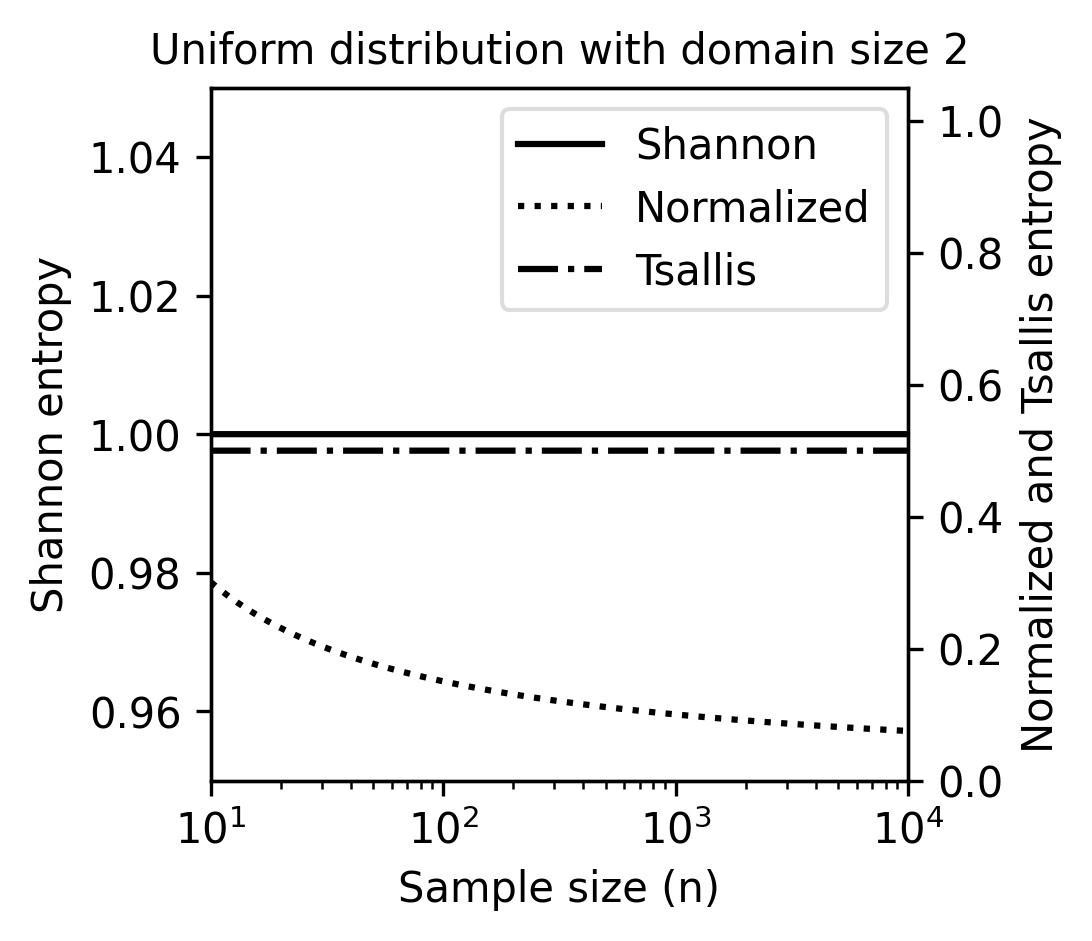

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3,3), dpi=300)
ax.set_title('Uniform distribution with domain size 2', fontdict={'fontsize':10})
ax.set_xscale('log')
ax.set_xticks([10,100,1000,10000])
ax.set_xlim(10, 10000)
ax.set_xlabel('Sample size (n)')
lns = ax.plot(data_2.index, data_2['Shannon'], entropy_lines['Shannon'], label=entropy_labels['Shannon'], color=entropy_colors['Shannon'])
ax.set_ylabel('Shannon entropy')
ax.set_ylim(0.95, 1.05)
ax.set_yticks([0.96, 0.98, 1.0, 1.02, 1.04])
ax2 = ax.twinx()
ax2.set_ylim(0, 1.05)
ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
lns += ax2.plot(data_2.index, data_2['Norm Shannon'], entropy_lines['Norm Shannon'], label=entropy_labels['Norm Shannon'], color=entropy_colors['Norm Shannon'])
ax2.set_ylabel('Normalized and Tsallis entropy')
lns += ax2.plot(data_2.index, data_2['Tsallis'], entropy_lines['Tsallis'], label=entropy_labels['Tsallis'], color=entropy_colors['Tsallis'])
labs = [l.get_label() for l in lns]
_ = plt.legend(lns, labs, loc='upper right', facecolor='white', framealpha=0.65)

## Example 3

Demonstration of how relative error grows with domain size. Entropy is estimated over the power law distribution, $f(x)=x^{-1}$, where relative error is averaged over T=100 trials.

In [ ]:
rng = np.random.default_rng()
N=1000000

def get_entropy_estimates_avg_rel_errors(D, N=N, trials=100, subsample_sizes=None):
  """
  Computes the average relative error for Shannon, Normalized, Tsallis entropies
  computed for the power law distribution, 𝑓(𝑥)=𝑥^{−1}, for domain size D,
  where the sample sizes range from 10 to n.
  Relative errors are averaged over T trials.

  args:
  - D: Domain size
  - N: max sample size
  - trials: number of trials for each subsample size, n

  Returns dataframe where each row corresponds to a subsample of size n.
  Columns:
    n: sumbsample size
    Shannon: shannon avg rel error
    Norm Shannon: norm shannon avg rel error
    Tsallis: tsallis avg rel error
  """
  print('computing average relative errors for power law distrubiton with D=%s, N=%s over T=%s trials' % (D, N, trials))
  # get true values
  pX = get_pX_power_law_dist(D)
  H = get_shannon_entropy(pX)
  NormH = get_normalized_shannon_entropy(pX, N=N)
  T = get_tsallis_entropy(pX)
  # set up avg relative errors lists for each n
  shannon_avg_rel_errors = []
  norm_shannon_avg_rel_errors = []
  tsallis_avg_rel_errors = []
  # Debugging: for Norm entropy
  log_N = math.log(N, 2)
  log_n = [] # math.log(n, 2)
  H_hats = []
  NormH_hats = []
  subsamples = len(subsample_sizes)
  for i, n in enumerate(subsample_sizes):
    if i % 10 == 0:
      print('%s/%s n=%s' % (i, subsamples, n))
    # get estimates
    shannon_cum_rel_error = 0
    norm_shannon_cum_rel_error = 0
    tsallis_cum_rel_error = 0
    # Debugging: Shannon and Norm entropy for debugging
    H_hat_cum = 0
    NormH_hat_cum = 0
    for _t in range(trials):
      # Draw samples from distribution
      samples = rng.choice(D, size=n, p=pX)
      # Estimate entropies from samples
      _, counts = np.unique(samples, return_counts=True)
      p_hat = pd.Series(counts / sum(counts))
      H_hat = get_shannon_entropy(p_hat)
      NormH_hat = get_normalized_shannon_entropy(p_hat, N=n)
      T_hat = get_tsallis_entropy(p_hat)
      # Compute error of estimates
      shannon_cum_rel_error += np.abs(H_hat - H) / H
      norm_shannon_cum_rel_error += np.abs(NormH_hat - NormH) / NormH
      tsallis_cum_rel_error += np.abs(T_hat - T) / T
      # Debugging:
      H_hat_cum += H_hat
      NormH_hat_cum += NormH_hat
    shannon_avg_rel_errors.append(shannon_cum_rel_error / trials)
    norm_shannon_avg_rel_errors.append(norm_shannon_cum_rel_error / trials)
    tsallis_avg_rel_errors.append(tsallis_cum_rel_error / trials)
    # Debugging
    log_n.append(math.log(n, 2))
    H_hats.append(H_hat_cum / trials)
    NormH_hats.append(NormH_hat_cum / trials)
  return pd.DataFrame({
      'n': subsample_sizes,
      'Shannon': shannon_avg_rel_errors,
      'Norm Shannon': norm_shannon_avg_rel_errors,
      'Tsallis': tsallis_avg_rel_errors,
      # included for debugging: log(n), log(N), H(X), H(Xn), H(Xn)/log(n), H(X)/log(N)
      'log(N)': [log_N]*subsamples,
      'H(X)': [H]*subsamples,
      'H(X)/log(N)': [H/log_N]*subsamples,
      'H(Xn)': H_hats,
      'H(Xn)/log(n)': NormH_hats,
      'log(n)':log_n
  }).set_index('n')

In [ ]:
# Want ~100 subsamples with size starting at 100 and going to N
steps = 100
step = N/steps
print('step size', int(step))
subsample_sizes = [100] + [int(i*step) for i in range(1, steps + 1)]
assert(subsample_sizes[-1] == N)
data_3_df_dict = dict() # map Domain size, D to the dataframe
Ds = [100, 1000, 10000]
for D in Ds:
  data_3_df_dict[D] = get_entropy_estimates_avg_rel_errors(D=D, N=1000000, trials=100, subsample_sizes=subsample_sizes)
  display(data_3_df_dict[D].head())

step size 10000
computing average relative errors for power law distrubiton with D=100, N=1000000 over T=100 trials
0/101 n=100
10/101 n=100000
20/101 n=200000
30/101 n=300000
40/101 n=400000
50/101 n=500000
60/101 n=600000
70/101 n=700000
80/101 n=800000
90/101 n=900000
100/101 n=1000000


,Shannon,Norm Shannon,Tsallis,log(N),H(X),H(X)/log(N),H(Xn),H(Xn)/log(n),log(n)
n,,,,,,,,,
100,0.126754,1.619739,0.014947,19.931569,5.31024,0.266424,4.637147,0.697960,6.643856
10000,0.003184,0.497865,0.001086,19.931569,5.31024,0.266424,5.302681,0.399067,13.287712
20000,0.001965,0.394581,0.000718,19.931569,5.31024,0.266424,5.308589,0.371549,14.287712
30000,0.001802,0.339323,0.000691,19.931569,5.31024,0.266424,5.306973,0.356827,14.872675
40000,0.001653,0.303462,0.000587,19.931569,5.31024,0.266424,5.309010,0.347273,15.287712


computing average relative errors for power law distrubiton with D=1000, N=1000000 over T=100 trials
0/101 n=100
10/101 n=100000
20/101 n=200000
30/101 n=300000
40/101 n=400000
50/101 n=500000
60/101 n=600000
70/101 n=700000
80/101 n=800000
90/101 n=900000
100/101 n=1000000


,Shannon,Norm Shannon,Tsallis,log(N),H(X),H(X)/log(N),H(Xn),H(Xn)/log(n),log(n)
n,,,,,,,,,
100,0.265905,1.202284,0.009874,19.931569,7.489046,0.375738,5.497670,0.827482,6.643856
10000,0.011053,0.483420,0.000745,19.931569,7.489046,0.375738,7.406266,0.557377,13.287712
20000,0.005477,0.387404,0.000557,19.931569,7.489046,0.375738,7.448186,0.521300,14.287712
30000,0.003255,0.335982,0.000470,19.931569,7.489046,0.375738,7.465771,0.501979,14.872675
40000,0.002934,0.300175,0.000391,19.931569,7.489046,0.375738,7.468432,0.488525,15.287712


computing average relative errors for power law distrubiton with D=10000, N=1000000 over T=100 trials
0/101 n=100
10/101 n=100000
20/101 n=200000
30/101 n=300000
40/101 n=400000
50/101 n=500000
60/101 n=600000
70/101 n=700000
80/101 n=800000
90/101 n=900000
100/101 n=1000000


,Shannon,Norm Shannon,Tsallis,log(N),H(X),H(X)/log(N),H(Xn),H(Xn)/log(n),log(n)
n,,,,,,,,,
100,0.387115,0.838655,0.011104,19.931569,9.532297,0.478251,5.842203,0.879339,6.643856
10000,0.057445,0.413833,0.000487,19.931569,9.532297,0.478251,8.984719,0.676167,13.287712
20000,0.035366,0.345679,0.000386,19.931569,9.532297,0.478251,9.195179,0.643572,14.287712
30000,0.026057,0.305226,0.000287,19.931569,9.532297,0.478251,9.283913,0.624226,14.872675
40000,0.020198,0.277431,0.000277,19.931569,9.532297,0.478251,9.339764,0.610933,15.287712


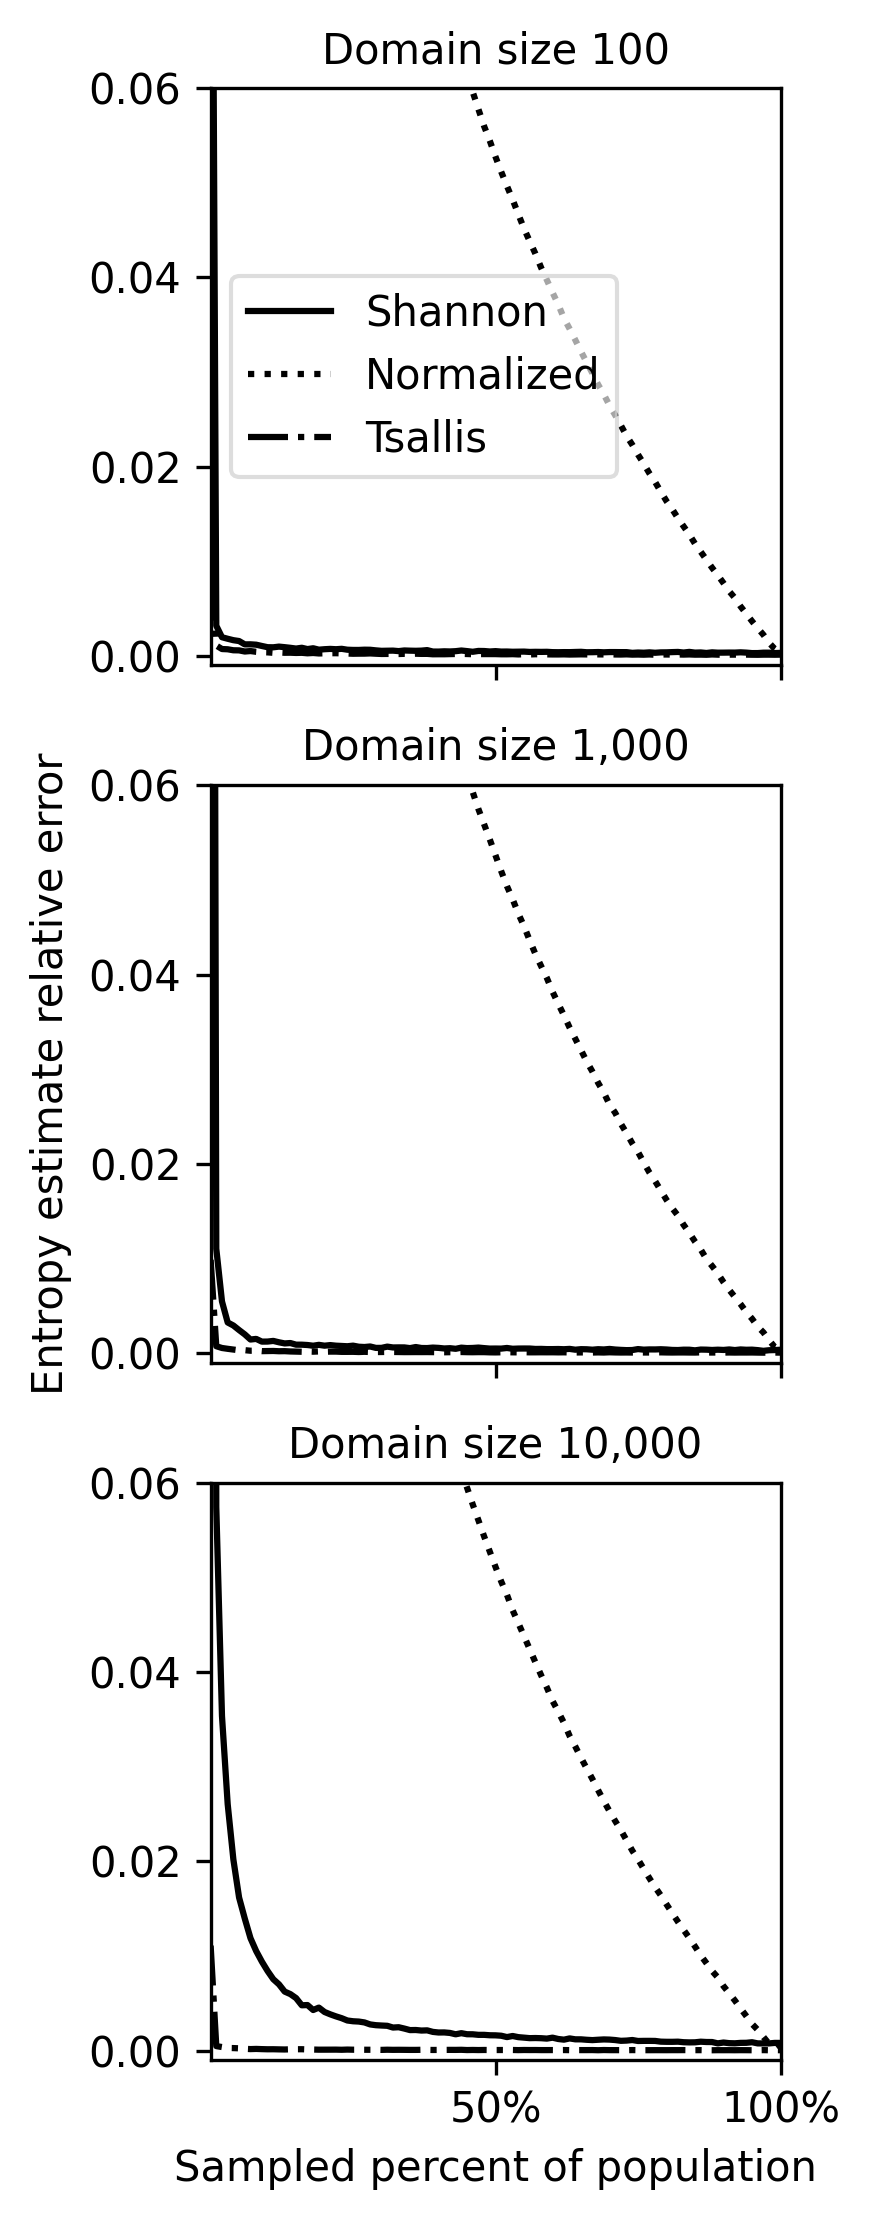

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(3, 7.5), sharey=True, sharex=True, dpi=300)
for i, (D, df) in enumerate(data_3_df_dict.items()):
  ax = axes[i]
  ax.set_title('Domain size %s'%f'{D:,}', fontdict={'fontsize':10})
  if i==1:ax.set_ylabel('Entropy estimate relative error')
  ax.set_xlim(0, N)
  ax.set_ylim(-0.001, 0.06)
  ax.set_yticks([0, 0.02, 0.04, 0.06])
  lns = ax.plot(df.index, df['Shannon'], entropy_lines['Shannon'], label=entropy_labels['Shannon'], color=entropy_colors['Shannon'])
  lns += ax.plot(df.index, df['Norm Shannon'], entropy_lines['Norm Shannon'], label=entropy_labels['Norm Shannon'], color=entropy_colors['Norm Shannon'])
  lns += ax.plot(df.index, df['Tsallis'], entropy_lines['Tsallis'], label=entropy_labels['Tsallis'], color=entropy_colors['Tsallis'])
  if i==0: ax.legend(lns, [l.get_label() for l in lns], loc='center left', facecolor='white', framealpha=0.65)
  if i == 2:
    #ax.set_xlabel('n')
    #ax.set_xticks([N/2, N], ['500,000', '1,000,000'])
    ax.set_xlabel('Sampled percent of population')
    ax.set_xticks([N/2, N], ['50%', '100%'])
plt.tight_layout()

Below shows what would happen if we used even larger domain sizes with same N.
i.e. Domain size 100,000 is only 10x smaller than N. This is a very flat power law distribution.

Note for this quick demonstration, T trials is smaller.

In [ ]:
# Want ~100 subsamples with size starting at 100 and going to N
steps = 100
step = N/steps
print('step size', int(step))
subsample_sizes = [100] + [int(i*step) for i in range(1, steps + 1)]
assert(subsample_sizes[-1] == N)
data_3_df_dict2 = dict() # map Domain size, D to the dataframe
Ds = [100, 1000, 10000, 100000]
for D in Ds:
  data_3_df_dict2[D] = get_entropy_estimates_avg_rel_errors(D=D, N=1000000, trials=10, subsample_sizes=subsample_sizes)
  display(data_3_df_dict2[D].head())

step size 10000
computing average relative errors for power law distrubiton with D=100, N=1000000 over T=10 trials
0/101 n=100
10/101 n=100000
20/101 n=200000
30/101 n=300000
40/101 n=400000
50/101 n=500000
60/101 n=600000
70/101 n=700000
80/101 n=800000
90/101 n=900000
100/101 n=1000000


,Shannon,Norm Shannon,Tsallis,log(N),H(X),H(X)/log(N),H(Xn),H(Xn)/log(n),log(n)
n,,,,,,,,,
100,0.142586,1.572241,0.016051,19.931569,5.31024,0.266424,4.553071,0.685306,6.643856
10000,0.002019,0.498348,0.000758,19.931569,5.31024,0.266424,5.304390,0.399195,13.287712
20000,0.002438,0.393222,0.000584,19.931569,5.31024,0.266424,5.303415,0.371187,14.287712
30000,0.001587,0.339684,0.000379,19.931569,5.31024,0.266424,5.308407,0.356923,14.872675
40000,0.001445,0.303242,0.000256,19.931569,5.31024,0.266424,5.308115,0.347214,15.287712


computing average relative errors for power law distrubiton with D=1000, N=1000000 over T=10 trials
0/101 n=100
10/101 n=100000
20/101 n=200000
30/101 n=300000
40/101 n=400000
50/101 n=500000
60/101 n=600000
70/101 n=700000
80/101 n=800000
90/101 n=900000
100/101 n=1000000


,Shannon,Norm Shannon,Tsallis,log(N),H(X),H(X)/log(N),H(Xn),H(Xn)/log(n),log(n)
n,,,,,,,,,
100,0.261972,1.214085,0.007290,19.931569,7.489046,0.375738,5.527129,0.831916,6.643856
10000,0.012865,0.480702,0.000793,19.931569,7.489046,0.375738,7.392699,0.556356,13.287712
20000,0.004277,0.389049,0.000479,19.931569,7.489046,0.375738,7.457017,0.521918,14.287712
30000,0.003075,0.336026,0.000400,19.931569,7.489046,0.375738,7.466018,0.501996,14.872675
40000,0.002657,0.301650,0.000362,19.931569,7.489046,0.375738,7.476906,0.489079,15.287712


computing average relative errors for power law distrubiton with D=10000, N=1000000 over T=10 trials
0/101 n=100
10/101 n=100000
20/101 n=200000
30/101 n=300000
40/101 n=400000
50/101 n=500000
60/101 n=600000
70/101 n=700000
80/101 n=800000
90/101 n=900000
100/101 n=1000000


,Shannon,Norm Shannon,Tsallis,log(N),H(X),H(X)/log(N),H(Xn),H(Xn)/log(n),log(n)
n,,,,,,,,,
100,0.373910,0.878269,0.007757,19.931569,9.532297,0.478251,5.968072,0.898284,6.643856
10000,0.054813,0.417780,0.000577,19.931569,9.532297,0.478251,9.009802,0.678055,13.287712
20000,0.035766,0.345121,0.000241,19.931569,9.532297,0.478251,9.191367,0.643306,14.287712
30000,0.024854,0.306839,0.000354,19.931569,9.532297,0.478251,9.295384,0.624997,14.872675
40000,0.019710,0.278067,0.000248,19.931569,9.532297,0.478251,9.344416,0.611237,15.287712


computing average relative errors for power law distrubiton with D=100000, N=1000000 over T=10 trials
0/101 n=100
10/101 n=100000
20/101 n=200000
30/101 n=300000
40/101 n=400000
50/101 n=500000
60/101 n=600000
70/101 n=700000
80/101 n=800000
90/101 n=900000
100/101 n=1000000


,Shannon,Norm Shannon,Tsallis,log(N),H(X),H(X)/log(N),H(Xn),H(Xn)/log(n),log(n)
n,,,,,,,,,
100,0.472100,0.583699,0.011031,19.931569,11.4954,0.576743,6.068419,0.913388,6.643856
10000,0.132576,0.301135,0.000339,19.931569,11.4954,0.576743,9.971381,0.750421,13.287712
20000,0.099333,0.256443,0.000353,19.931569,11.4954,0.576743,10.353522,0.724645,14.287712
30000,0.083250,0.228580,0.000266,19.931569,11.4954,0.576743,10.538412,0.708575,14.872675
40000,0.072650,0.209046,0.000123,19.931569,11.4954,0.576743,10.660261,0.697309,15.287712


The cell below generates **Figure 3** of the paper: *Relative error grows with domain size (example 3).*

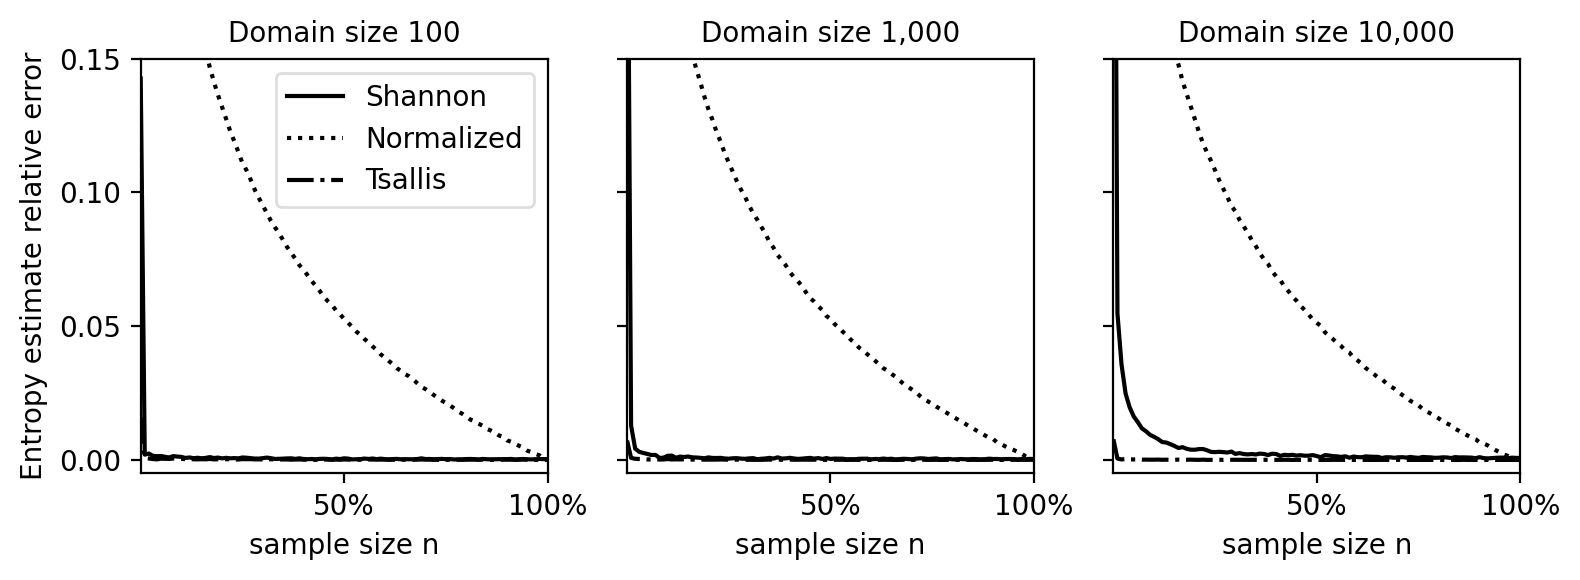

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True, sharex=True, dpi=200)
for i, (D, df) in enumerate(data_3_df_dict2.items()):
  if i==3: break
  ax = axes[i]
  ax.set_title('Domain size %s'%f'{D:,}', fontdict={'fontsize':10})
  ax.set_xlabel('sample size n')
  ax.set_xticks([N/2, N], ['50%', '100%'])
  ax.set_xlim(0, N)
  lns = ax.plot(df.index, df['Shannon'], entropy_lines['Shannon'], label=entropy_labels['Shannon'], color=entropy_colors['Shannon'])
  lns += ax.plot(df.index, df['Norm Shannon'], entropy_lines['Norm Shannon'], label=entropy_labels['Norm Shannon'], color=entropy_colors['Norm Shannon'])
  lns += ax.plot(df.index, df['Tsallis'], entropy_lines['Tsallis'], label=entropy_labels['Tsallis'], color=entropy_colors['Tsallis'])
  if i == 0:
    _ = ax.legend(lns, [l.get_label() for l in lns], loc='upper right', facecolor='white', framealpha=0.65)
    ax.set_ylabel('Entropy estimate relative error')
    ax.set_ylim(-0.005, 0.15)
    ax.set_yticks([0, 0.05, 0.1, 0.15])
plt.tight_layout()

The cell below generates **Figure 9** of the paper: *Figure 3 replicated using a Zipf distribution with different $a$ coefficients.*

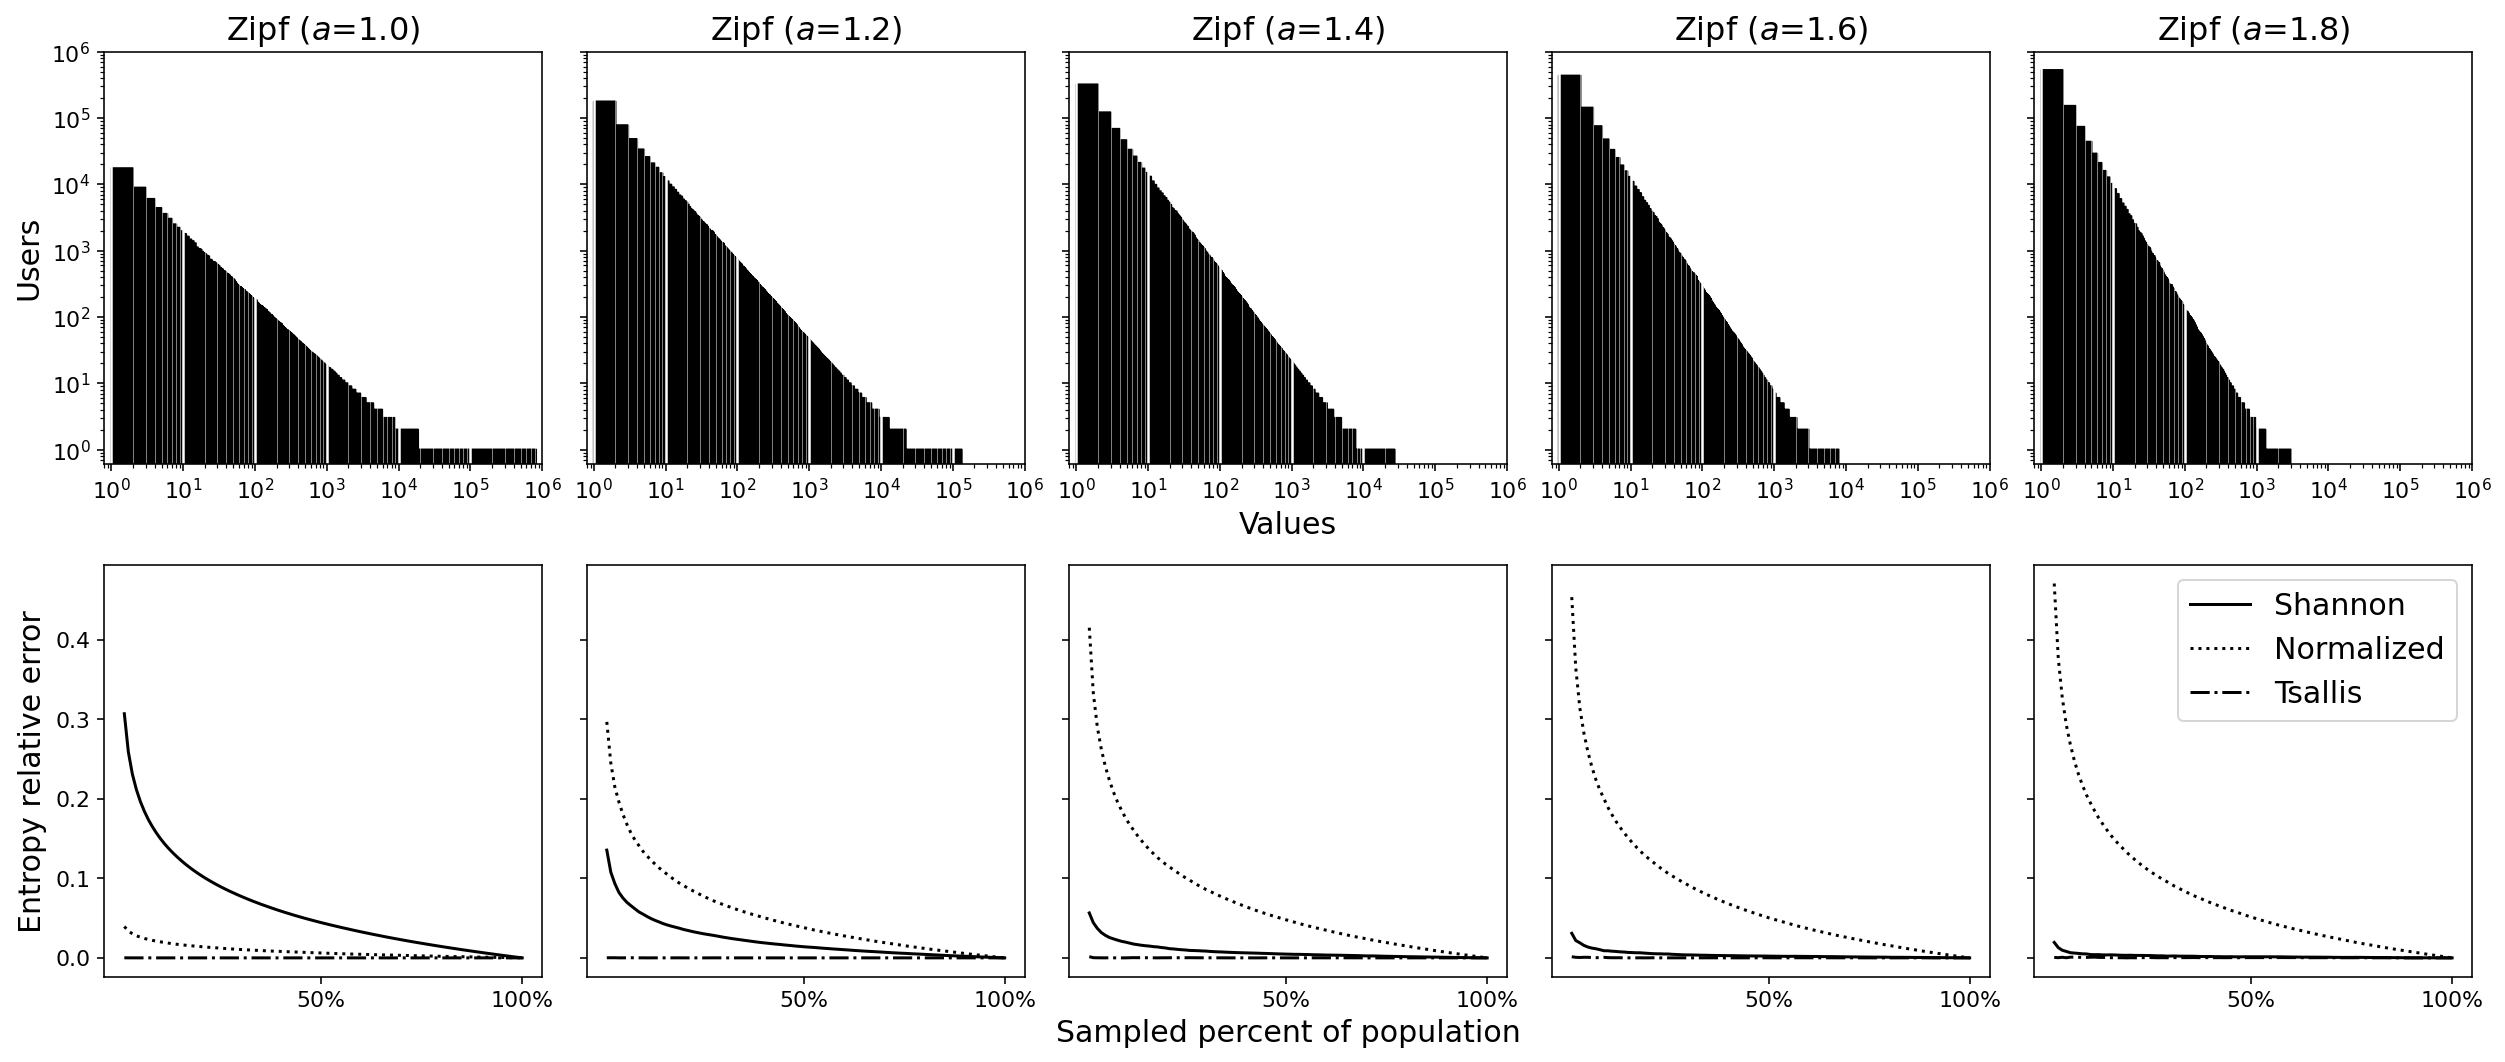

In [ ]:
import matplotlib.pyplot as plt
import concurrent.futures
import numpy as np

population = 1_000_000
num_trials = 20
As = [1.0, 1.2, 1.4, 1.6, 1.8]
figsize = (17.5, 7.5)
fontsize = 15
workers = 10

def plot1(a, ax, population):
  """Generates the frequency distribution plot (top row)."""
  rng = np.random.default_rng()
  samples = rng.zipf(a=a+10e-10, size=population)
  _, ys = np.unique(samples, return_counts=True)
  ys = sorted(ys, reverse=True)
  xs = np.arange(1, len(ys) + 1)
  ax.fill_between(
      [xt for x in xs for xt in [x, x+1-10e-10]],
      [yt for y in ys for yt in [y, y]],
      color='black')
  ax.set_xscale('log')
  ax.set_yscale('log')
  ax.grid(axis='x', which="major", linewidth=1.25, color='#ffff')
  ax.grid(axis='x', which="minor", linewidth=0.25, color='#ffff')
  ax.set_xlim(0.8, population)
  ax.set_ylim(top=population)

def run_trial(a, population, sample_sizes, seed):
  """
  Worker function that generates one large sample set and computes
  entropy estimates for all sample sizes using prefixes.
  """
  rng = np.random.default_rng(seed)
  all_samples = rng.zipf(a=a + 10e-10, size=population)
  trial_Hs, trial_Ns, trial_Ts = [], [], []

  for n in sample_sizes:
    sub_samples = all_samples[:n]
    _, counts = np.unique(sub_samples, return_counts=True)
    p_hat = counts / n
    H_hat = entropy(p_hat, base=2)
    N_hat = H_hat / np.log2(n)
    T_hat = 1 - np.sum(p_hat**2)
    trial_Hs.append(H_hat)
    trial_Ns.append(N_hat)
    trial_Ts.append(T_hat)
  return trial_Hs, trial_Ns, trial_Ts

def plot2(a, population, num_trials, ax, points=100):
  """Generates the entropy relative error plot (bottom row) with parallel trials."""
  sample_sizes = np.linspace(population//points, population, points).astype(int)

  with concurrent.futures.ThreadPoolExecutor(max_workers=workers) as pool:
    seeds = [np.random.randint(0, 2**32) for _ in range(num_trials)]
    fs = [pool.submit(run_trial, a, population, sample_sizes, s) for s in seeds]
    results = [f.result() for f in concurrent.futures.as_completed(fs)]
    Hs_all, Ns_all, Ts_all = zip(*results)
    avg_Hs = np.mean(Hs_all, axis=0)
    avg_Ns = np.mean(Ns_all, axis=0)
    avg_Ts = np.mean(Ts_all, axis=0)

  # Relative error relative to the "full population" estimate (the 100% point)
  H_pop, N_pop, T_pop = avg_Hs[-1], avg_Ns[-1], avg_Ts[-1]
  H_errs = np.abs(avg_Hs - H_pop) / H_pop
  N_errs = np.abs(avg_Ns - N_pop) / N_pop
  T_errs = np.abs(avg_Ts - T_pop) / T_pop

  ax.plot(sample_sizes, H_errs, label='Shannon', ls='-', color='black')
  ax.plot(sample_sizes, N_errs, label='Normalized', ls=':', color='black')
  ax.plot(sample_sizes, T_errs, label='Tsallis', ls='-.', color='black')
  ax.set_xticks([population//2, population])
  ax.set_xticklabels(['50%', '100%'])

# Main execution loop
fig, axs = plt.subplots(
    2, len(As), sharey='row', figsize=figsize, facecolor='white')

for idx, a in enumerate(As):
  axs[0,idx].set_title(f'Zipf ($a$={a})', fontsize=fontsize+1)
  plot1(a, axs[0,idx], population)
  plot2(a, population=population, num_trials=num_trials, ax=axs[1,idx])

# Final Styling and Labels
for ax in (a for ax in axs for a in ax):
  ax.xaxis.set_tick_params(labelsize=fontsize-4)
  ax.yaxis.set_tick_params(labelsize=fontsize-4)

axs[0,len(As)//2].set_xlabel('Values', fontsize=fontsize)
axs[1,len(As)//2].set_xlabel('Sampled percent of population', fontsize=fontsize)
axs[0,0].set_ylabel(f'Users', fontsize=fontsize)
axs[1,0].set_ylabel(f'Entropy relative error', fontsize=fontsize)
axs[1,len(As)-1].legend(fontsize=fontsize)

fig.tight_layout()
plt.show()